#1. LOAD LIBRARY AND FOLDER LOCATION

In [1]:
#Load library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import skew, kurtosis, iqr
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#재현성을 위한 랜덤 시드 설정
np.random.seed(42)

#시각화 스타일 설정
sns.set_theme(style = 'whitegrid')


data_path = os.path.join(os.getcwd(), 'data','A_DeviceMotion_data')
if os.path.exists(data_path):
    print(f"데이터 경로 확인: {data_path}")
else:
    print("경로를 찾을 수 없습니다.")

데이터 경로 확인: /Users/linerenza/Desktop/비정형데이터분석/data/A_DeviceMotion_data


# Diamonds 데이터 로그 및 미리보기

In [2]:
# seaborn 내장 diamonds 데이터셋 로드
df = sns.load_dataset('diamonds')

#데이터 차원 확인
print(f'Data Shape: {df.shape}')

#데이터 기초 정보 확인 (컬럼 타입, 결측치 등)
print(df.info())

#상위 5개 데이터 미리보기
display(df.head())

Data Shape: (53940, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# 가겯 분포와 왜도/첨도

skewness: 1.618395283383529
kurtosis (Pearson): 5.177695759248689


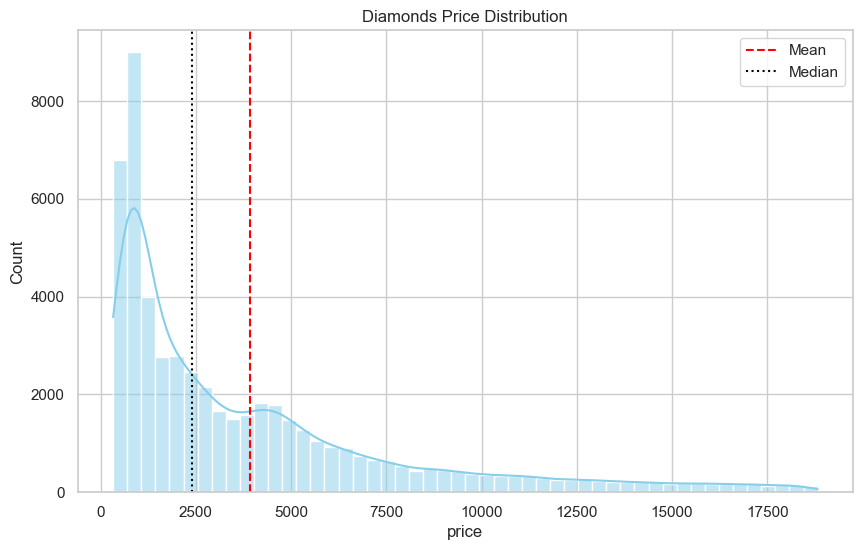

In [3]:
#가격 데티터 추출
price = df['price']

#왜도와 첨도 계산
print('skewness:', skew(price,bias = False))
print('kurtosis (Pearson):', kurtosis(price, fisher = False, bias = False))

#히스토그램 및 밀도 함수 시각화
plt.figure(figsize = (10,6))
sns.histplot(price, bins = 50, kde = True, color = 'skyblue')

#편균관 중앙값 표시
plt.axvline(price.mean(), color = 'red', linestyle ='--', label = 'Mean')
plt.axvline(price.median(), color = 'black', linestyle =':', label = 'Median')

plt.legend()
plt.title('Diamonds Price Distribution')
plt.show()

# 색상별 가격 왜도/첨도 그룹 분석

=== 색상별 가격 분포 특성 ===
   color   level_1     price
0      D  skewness  2.105520
1      D  kurtosis  7.673960
2      E  skewness  2.169836
3      E  kurtosis  7.899241
4      F  skewness  1.754865
5      F  kurtosis  5.820251
6      G  skewness  1.499324
7      G  kurtosis  4.723282
8      H  skewness  1.383031
9      H  kurtosis  4.448713
10     I  skewness  1.158572
11     I  kurtosis  3.421068
12     J  skewness  1.035449
13     J  kurtosis  3.284350


/var/folders/tr/s34nl3mn5y97mk216nvs_dk00000gn/T/ipykernel_21746/2557403148.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_color = (df.groupby('color')['price']


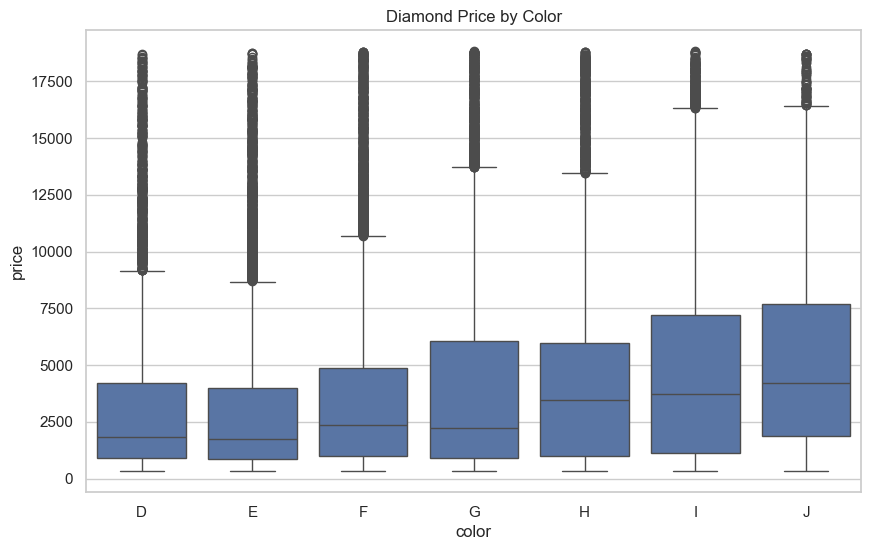

In [4]:
#색상 별로 가격의 왜도와 첨도를 계산한다
#apply와 lambda 함수를 사용하여 여러 통계량을 반환

by_color = (df.groupby('color')['price']
            .apply(lambda s: pd.Series({
                'skewness': skew(s, bias = False),
                'kurtosis' : kurtosis(s, fisher = False, bias = False)
            })).reset_index())

print("=== 색상별 가격 분포 특성 ===")
print(by_color)

#결과 해석을 위한 boxplot 시각화
plt.figure(figsize= (10,6))
sns.boxplot(x = 'color', y = 'price', data = df)
plt.title('Diamond Price by Color')
plt.show()

In [5]:
by_color = (df.groupby('color')['price']
            .apply(lambda s: pd.Series({
                'skewness': skew(s, bias = False),
                'kurtosis' : kurtosis(s, fisher = False, bias = False)
            })).unstack().reset_index())
print(by_color)
print(by_color.values.tolist())

  color  skewness  kurtosis
0     D  2.105520  7.673960
1     E  2.169836  7.899241
2     F  1.754865  5.820251
3     G  1.499324  4.723282
4     H  1.383031  4.448713
5     I  1.158572  3.421068
6     J  1.035449  3.284350
[['D', 2.105519755551446, 7.673959991913999], ['E', 2.169836341147625, 7.89924127219687], ['F', 1.7548647244054723, 5.820250844779849], ['G', 1.4993236225720037, 4.723281659574809], ['H', 1.3830311346827746, 4.448712663577679], ['I', 1.1585722914870473, 3.4210678959546286], ['J', 1.0354488947473786, 3.2843501321470043]]


/var/folders/tr/s34nl3mn5y97mk216nvs_dk00000gn/T/ipykernel_21746/2964979004.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_color = (df.groupby('color')['price']


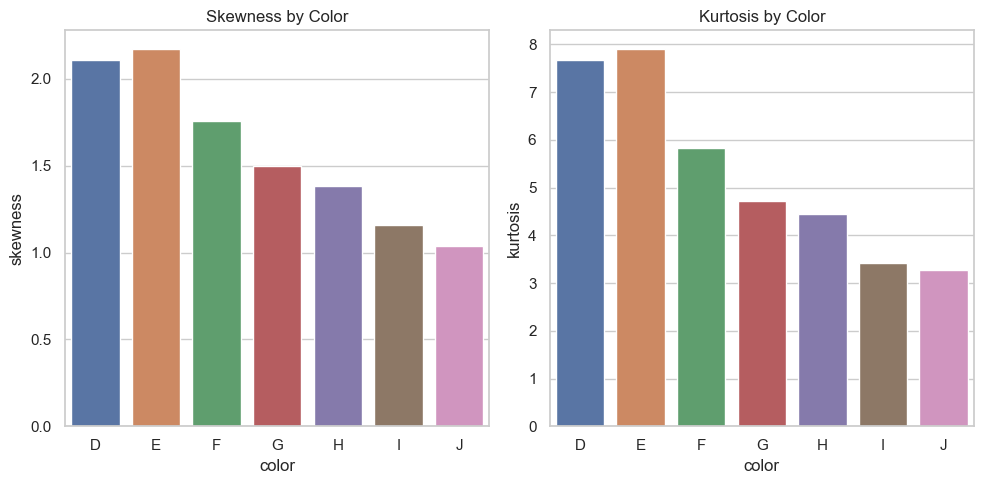

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(x='color', y='skewness', data=by_color, hue = 'color')
plt.title('Skewness by Color')

plt.subplot(1,2,2)
sns.barplot(x='color', y='kurtosis', data=by_color, hue = 'color')
plt.title('Kurtosis by Color')

plt.tight_layout()
plt.show()

# 센서 특질 확정: RMS,RSS, IQR, 첨도

In [22]:
#HAR_total 파일 로드
HAR_total = pd.read_pickle(data_path + '/HAR_total.pkl')
print(HAR_total.head())

   Unnamed: 0  attitude.roll  attitude.pitch  attitude.yaw  gravity.x  \
0           0      -2.116381       -1.077507     -2.261502  -0.404768   
1           1      -2.148154       -1.049759     -2.284278  -0.417081   
2           2      -2.153824       -1.026749     -2.297008  -0.432082   
3           3      -2.142509       -1.012749     -2.290595  -0.445311   
4           4      -2.130486       -1.007262     -2.274149  -0.452661   

   gravity.y  gravity.z  rotationRate.x  rotationRate.y  rotationRate.z  \
0   0.880780   0.245713       -1.264215       -1.027909       -0.947909   
1   0.867303   0.271686       -1.162024       -0.269118       -0.848823   
2   0.855621   0.284961       -0.665042        0.520170       -0.726722   
3   0.848291   0.286507       -0.079809        0.055322       -0.604534   
4   0.845372   0.283600        0.456097       -0.186877       -0.441315   

   userAcceleration.x  userAcceleration.y  userAcceleration.z exp_no  id  \
0            0.282683           -0

In [11]:
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def rss(x):
    return np.sqrt(np.sum(np.square(x)))

# 그룹별 다양한 통계량 한 번에 추출
har_summary_extend = (
    HAR_total
    .groupby(['id', 'exp_no', 'activity'])
    .agg(
        magAcc_mean=('maguserAcceleration', 'mean'),
        magAcc_sd=('maguserAcceleration', 'std'),
        magAcc_skew=('maguserAcceleration', lambda x: skew(x, bias=False)),
        magAcc_rms=('maguserAcceleration', rms),
        magAcc_rss=('maguserAcceleration', rss),
        magAcc_iqr=('maguserAcceleration', lambda x: iqr(x, rng=(25, 75))),
        magAcc_kurt=('maguserAcceleration', lambda x: kurtosis(x, fisher=False, bias = False)),

        magRot_mean=('magrotationRate', 'mean'),
        magRot_sd=('magrotationRate', 'std'),
        magRot_skew=('magrotationRate', lambda x: skew(x, bias=False)),
        magRot_rms=('magrotationRate', rms),
        magRot_rss=('magrotationRate', rss),
        magRot_iqr=('magrotationRate', lambda x: iqr(x, rng=(25, 75))),
        magRot_kurt=('magrotationRate', lambda x: kurtosis(x, fisher=False, bias = False))
    )
    .reset_index()
)

print("Expanded features shape:", har_summary_extend.shape)
display(har_summary_extend.head(5))

Expanded features shape: (360, 17)


,id,exp_no,activity,magAcc_mean,magAcc_sd,magAcc_skew,magAcc_rms,magAcc_rss,magAcc_iqr,magAcc_kurt,magRot_mean,magRot_sd,magRot_skew,magRot_rms,magRot_rss,magRot_iqr,magRot_kurt
0,1,1,dws,0.501065,0.262767,1.140624,0.565750,23.673799,0.336092,5.204329,2.050740,1.219460,0.803248,2.385742,99.831278,1.705448,3.011956
1,1,11,dws,0.508985,0.279252,1.499335,0.580483,17.375745,0.331943,7.360827,2.079373,1.218075,0.726392,2.409531,72.125131,1.719327,2.915536
2,1,12,ups,0.480549,0.265723,1.511764,0.549062,17.926694,0.343959,8.182422,2.474843,1.302956,0.800285,2.796596,91.307900,1.838639,3.350890
3,1,13,sit,0.017672,0.015293,5.197941,0.023370,2.370859,0.010806,54.387429,0.044123,0.066350,4.943210,0.079679,8.083395,0.036880,38.845216
4,1,14,std,0.025681,0.017401,1.863807,0.031019,1.567308,0.018296,7.560645,0.078551,0.075889,2.236386,0.109211,5.518133,0.085203,10.373218


In [21]:
#결과 저장
csv_path = f"{data_path}/HAR_Statistical_Analysis.csv"
pkl_path = f"{data_path}/HAR_Statistical_Analysis.pkl"

har_summary_extend.to_csv(csv_path, index=False)
har_summary_extend.to_pickle(pkl_path)

print("저장 완료")

저장 완료


In [12]:
# 데이터 타입 확인
print("----- 데이터 타입 확인 -----")
print(har_summary_extend.dtypes)

# activity 컬럼을 category 타입으로 변환
har_summary_extend = har_summary_extend.assign(
    activity=har_summary_extend['activity'].astype('category')
)

# 변환 결과 확인
print("\n----- 변환 후 데이터 타입 -----")
print(har_summary_extend['activity'].dtype)

----- 데이터 타입 확인 -----
id              object
exp_no          object
activity        object
magAcc_mean    float64
magAcc_sd      float64
magAcc_skew    float64
magAcc_rms     float64
magAcc_rss     float64
magAcc_iqr     float64
magAcc_kurt    float64
magRot_mean    float64
magRot_sd      float64
magRot_skew    float64
magRot_rms     float64
magRot_rss     float64
magRot_iqr     float64
magRot_kurt    float64
dtype: object

----- 변환 후 데이터 타입 -----
category


# 불필요한 변수 제거

In [14]:
# 불필요한 식별자 컬럼 제거
cols_to_drop = ['id', 'exp_no']
har_summary_extend2 = har_summary_extend.drop(columns=cols_to_drop)

# 데이터 크기 비교
print(f"Original shape: {har_summary_extend.shape}")
print(f"New shape: {har_summary_extend2.shape}")

# 결과 확인
print("\nPreview (first 5 rows):")
display(har_summary_extend2.head())

Original shape: (360, 17)
New shape: (360, 15)

Preview (first 5 rows):


,activity,magAcc_mean,magAcc_sd,magAcc_skew,magAcc_rms,magAcc_rss,magAcc_iqr,magAcc_kurt,magRot_mean,magRot_sd,magRot_skew,magRot_rms,magRot_rss,magRot_iqr,magRot_kurt
0,dws,0.501065,0.262767,1.140624,0.565750,23.673799,0.336092,5.204329,2.050740,1.219460,0.803248,2.385742,99.831278,1.705448,3.011956
1,dws,0.508985,0.279252,1.499335,0.580483,17.375745,0.331943,7.360827,2.079373,1.218075,0.726392,2.409531,72.125131,1.719327,2.915536
2,ups,0.480549,0.265723,1.511764,0.549062,17.926694,0.343959,8.182422,2.474843,1.302956,0.800285,2.796596,91.307900,1.838639,3.350890
3,sit,0.017672,0.015293,5.197941,0.023370,2.370859,0.010806,54.387429,0.044123,0.066350,4.943210,0.079679,8.083395,0.036880,38.845216
4,std,0.025681,0.017401,1.863807,0.031019,1.567308,0.018296,7.560645,0.078551,0.075889,2.236386,0.109211,5.518133,0.085203,10.373218


# 10 fold CV

In [15]:
# 1. 입력 변수(X)와 타깃 변수(y) 분리
X = har_summary_extend2.drop(columns='activity')
y = har_summary_extend2['activity']

# 2. 모델 정의
clf = DecisionTreeClassifier(random_state=42)

# 3. 10-fold stratified cross validation 설정, Stratified K-Fold 설정 (10개로 분할)
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# 4. 교차검증 수행
scores = cross_val_score(
    estimator=clf,
    X=X,
    y=y,
    cv=cv,
    scoring='accuracy'
)

# 5. 결과 출력
print("Cross-validation scores:")
print(scores)

print(f"\nMean accuracy: {scores.mean():.4f}")
print(f"Standard deviation: {scores.std():.4f}")
print(f"Mean +/- Std: {scores.mean():.4f} +/- {scores.std():.4f}")

Cross-validation scores:
[0.77777778 0.66666667 0.75       0.86111111 0.72222222 0.83333333
 0.86111111 0.86111111 0.83333333 0.83333333]

Mean accuracy: 0.8000
Standard deviation: 0.0643
Mean +/- Std: 0.8000 +/- 0.0643


# PCA 수행 (표준화 표함)

In [16]:
#1. 틀성(features)과 label 분리
features = har_summary_extend2.drop(columns = ['activity'])
labels = har_summary_extend2['activity']

#2. 데이터 표준화(standarization) - PCA 전 필수 과정
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

#3. PCA 모델 생성 및 학습
pca = PCA()
pca.fit(X_scaled)

#4. 설명된 분산 비율 확인 (Explained variance ratio)
print('Explained variance ratio (first 5 components)')
print(pca.explained_variance_ratio_[:5])

Explained variance ratio (first 5 components)
[0.70973887 0.17580289 0.04275325 0.03032461 0.02404431]


# scree plot

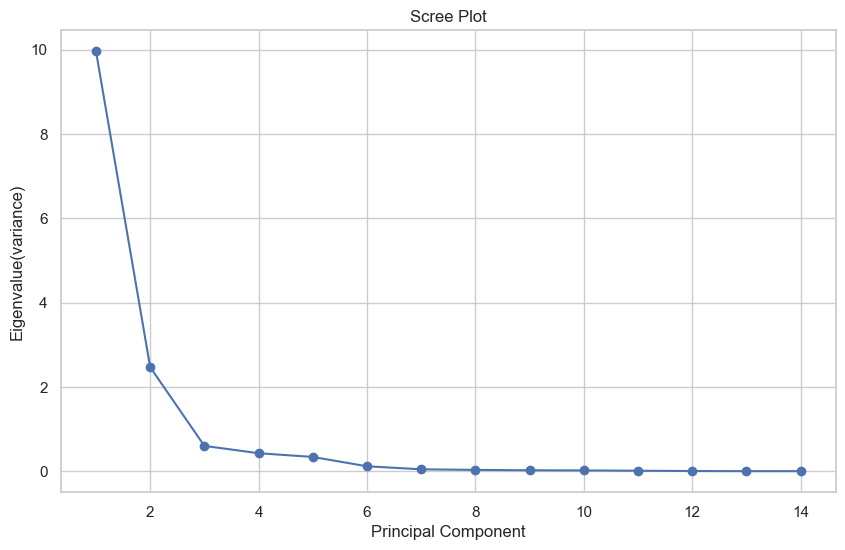

In [17]:
#PCA model에서 설명된 분산 (고유값) 추출
exp_var = pca.explained_variance_
n_comp = len(exp_var)

#scree plot visualization
plt.figure(figsize = (10,6))
plt.plot(
    np.arange(1,n_comp +1),
    exp_var,
    marker ='o', linestyle='-'
)
plt.title ('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue(variance)')
plt.grid(True)
plt.show()

# 로딩 추출 및 해석

In [18]:
#PCA 로딩 (Components) dataframes 생성
#행 원본 변수명, 열 = PC1, PC2,...

loading = pd.DataFrame(
    pca.components_.T,
    index = features.columns,
    columns = [f'PC{i+1}' for i in range(pca.n_components_)]
)

#결과 확인 : 상위 4개 PC의 로딩 값
print("PCA loading (First 4 Pcs, First 8 features)")
print(loading.iloc[:8, :4])

PCA loading (First 4 Pcs, First 8 features)
                  PC1       PC2       PC3       PC4
magAcc_mean  0.302937  0.123583 -0.125337  0.007935
magAcc_sd    0.300298  0.127516 -0.090322 -0.016460
magAcc_skew -0.154466  0.506405  0.373650  0.062221
magAcc_rms   0.303659  0.125716 -0.116330  0.002713
magAcc_rss   0.279056  0.117345 -0.166056  0.633665
magAcc_iqr   0.300788  0.119038 -0.125774 -0.016799
magAcc_kurt -0.116697  0.519167  0.518107  0.118243
magRot_mean  0.308820  0.075866  0.073434 -0.209541


# 주요 주성분(PC)별 상위 변수 선택

In [19]:
#pc1 ~ pc3에서 각각 절대값이 가장 큰 상위 2개 변수 추출
top_vars ={}
for i in range(3):
    pc = f'PC{i + 1}'
    #해당 PC의 로딩 절대값을 기존으로 내림차순 정렬 후 상위 2개 인덱스(변수명) 추출
    top_vars[pc] = loading[pc].abs().sort_values(ascending = False).head(2).index.tolist()
print("PC별 상위 변수:", top_vars)

#추출된 변수들을 하나의 리스트로 합치고 중복 제거 (Set 활용)
selected_features = sorted(set(sum(top_vars.values(),[])))

print("최종 선택 변수:", selected_features)
print(f'선택된 변수 개수: {len(selected_features)}')


PC별 상위 변수: {'PC1': ['magRot_mean', 'magRot_rms'], 'PC2': ['magAcc_kurt', 'magAcc_skew'], 'PC3': ['magAcc_kurt', 'magRot_skew']}
최종 선택 변수: ['magAcc_kurt', 'magAcc_skew', 'magRot_mean', 'magRot_rms', 'magRot_skew']
선택된 변수 개수: 5


# 선택 변수로 분류 성능 평가

In [20]:
#선택된 변수만 추출
X_sel = features[selected_features]

#분류기 및 CV 설정 (이전과 동일)
clf = DecisionTreeClassifier(random_state = 42)
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)

#1. 전제 특징을 사용한 성능 평가 (Baseline)
scores_all = cross_val_score(clf, features, labels, cv=cv, scoring = 'accuracy')

#2. 선택된 특징 (PCA 기반)을 사용한 성능 평가
score_sel = cross_val_score(clf, X_sel, labels, cv=cv, scoring = 'accuracy')

#결과 출력 및 비교
print(f'전제 특질 ({features.shape[1]}개) CV accuracy : {scores_all.mean():.4f} (+/- {scores_all.std():.4f})')
print(f'선택 특질({X_sel.shape[1]}개) CV accuracy : {scores_all.mean():.4f} (+/- {scores_all.std():.4f})')

#성능 차이 확인
diff = score_sel.mean() - scores_all.mean()
print(f'성능 차이 : {diff:.4f} (양수면 선택 특질이 더 우수)')

전제 특질 (14개) CV accuracy : 0.8000 (+/- 0.0643)
선택 특질(5개) CV accuracy : 0.8000 (+/- 0.0643)
성능 차이 : -0.1472 (양수면 선택 특질이 더 우수)
